<div style="text-align: center; margin: auto; background:#b4cc3d; padding:10px; color:white; font-family:Calibri ;">
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTaJWG7PzF3toxaRMB1-JicpqMgJuEXATd0fg&" style="width:120px; padding-top: 20px;">
    <h1  style="font-size:2.8rem">Data Mining Project: ABCDEats Customer Data</h1>
    <h2  style="font-size:2rem">Value Based Segmentation</h2>
    <p style='font-size:1.2rem;'>NOVA Information Management School </p>    
    <p style='font-size:1.2rem;'>Master in Data Science and Advanced Analytics</p>    
    <img src="https://cdni.iconscout.com/illustration/premium/thumb/food-delivery-service-by-scooter-illustration-download-in-svg-png-gif-file-formats--on-pack-e-commerce-shopping-illustrations-4403764.png" style="width:33rem;">
    <p style='font-size:1.3rem; padding:0; margin:0; font-weight:bold;'>Group 41 members:</p>
    <ul style='font-size:1.2rem; list-style-position: inside; padding-left:0; border:none;'>
        <li>Elcano Gaspar (20241021)</li>
        <li>Gasper Pereira (20230984)</li>
        <li>Pedro Costa (20222121)</li>
        <li>Rita Wang (20240551)</li>
    </ul> 
    <br>
    <p style='font-size:1.2rem; '>      Fall/Spring Semester 2024-2025</p>
</div>

<h1>0. Imports and Dataset Loading</h1>

In [325]:
# !pip install minisom
# !pip install minisom --upgrade
# !pip install sns --upgrade
#!pip install --upgrade pip setuptools wheel

In [326]:
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as GridSpec
import warnings

from itertools import combinations
from collections import Counter


from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler


from functions import * 

from scipy.stats import skew
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering

#!pip install minisom --upgrade
from minisom import MiniSom
from matplotlib.patches import RegularPolygon, Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm, colorbar
from matplotlib import colors as mpl_colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, DBSCAN, estimate_bandwidth
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib import cm
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from numpy.linalg import eig


In [327]:
df = pd.read_csv("PREPROCESSED_DATASET.csv")

# Value-Behavior Clustering Solution

In [328]:
value_cols = ['total_spent_log',
                'total_orders_log',
                'spend_per_vendor_log',
                "total_spent_chain_log"]

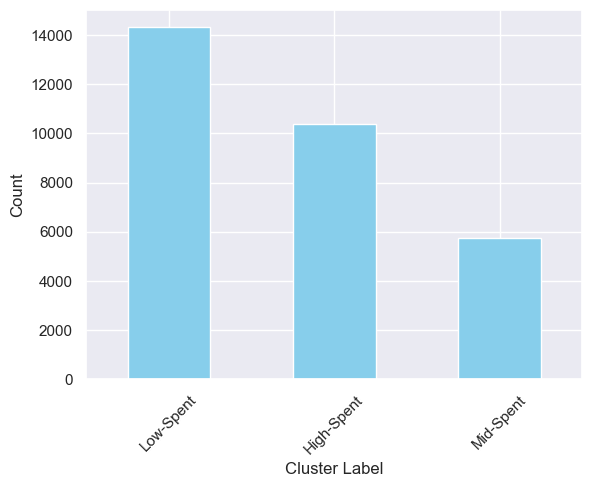

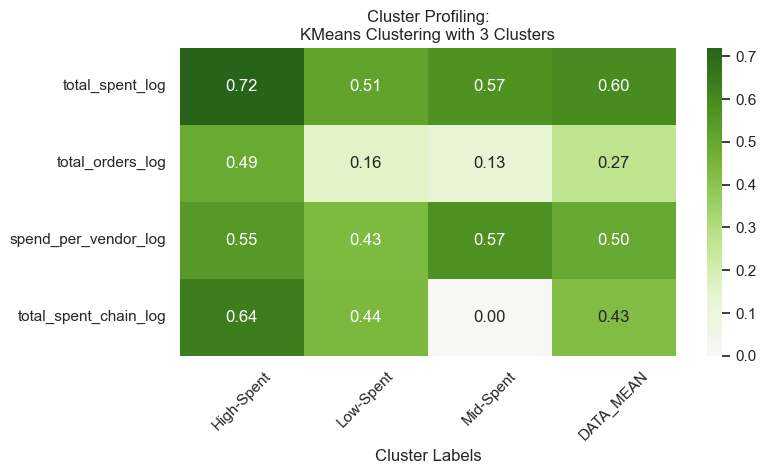

In [329]:
kmclust = KMeans(n_clusters=3, init='k-means++', n_init=15, random_state=42)
km_labels = kmclust.fit_predict(df[value_cols])
mapping = {0: 'High-Spent', 1: 'Low-Spent', 2: 'Mid-Spent'}

km_labels = pd.Series(km_labels, name='labels', index=df.index)
km_labels = km_labels.map(mapping)

df_concat = pd.concat((df[value_cols], pd.Series(km_labels, name='labels', index=df.index)), axis=1)

# mapping = {0: 'High-Spent', 1: 'Low-Spent', 2: 'Mid-Spent'}
# df_concat['labels'] = df_concat['labels'].map(mapping)
df_concat['labels'].value_counts().plot(kind='bar', color='skyblue')
plt.xticks(rotation=45)
plt.xlabel('Cluster Label')
plt.ylabel('Count')




fig, ax = plt.subplots(figsize=(8,4))
km_profile = df_concat.groupby('labels').mean().T

data_mean = df[value_cols].mean().T
data_mean = pd.DataFrame(data_mean, columns=['DATA_MEAN'])

df_all = pd.concat([km_profile, data_mean], axis=1)

sns.heatmap(df_all,
            center=0, annot=True, cmap="PiYG", fmt=".2f",
            ax=ax)
plt.xticks(rotation=45)
ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 3 Clusters")
plt.show()

In [330]:

km_profile

labels,High-Spent,Low-Spent,Mid-Spent
total_spent_log,0.719434,0.514747,0.571605
total_orders_log,0.494013,0.162293,0.127838
spend_per_vendor_log,0.546705,0.433836,0.574958
total_spent_chain_log,0.637835,0.441686,0.000000


In [331]:
df_all

,High-Spent,Low-Spent,Mid-Spent,DATA_MEAN
total_spent_log,0.719434,0.514747,0.571605,0.595231
total_orders_log,0.494013,0.162293,0.127838,0.268843
spend_per_vendor_log,0.546705,0.433836,0.574958,0.498925
total_spent_chain_log,0.637835,0.441686,0.000000,0.425208


In [332]:
r2 = get_rsq(df_concat, value_cols, 'labels')
r2

0.6014814456162794

# Preference Clustering Solution

In [333]:
preferences_cols = ["Asian_Street_percent", "Other_Chinese_percent", "Italian_American_percent", "AM_preference_percent"]

In [335]:
som_data = df[preferences_cols].values

neigh = 'gaussian'
topol = 'hexagonal'
n_feats = len(preferences_cols)
activation_distc = 'cosine'

cov_matrix = np.cov(df[preferences_cols].T)
eigenvalues, _ = eig(cov_matrix)
eigenvalues = sorted(eigenvalues.round(3), reverse=True)
ratio = eigenvalues[0] / eigenvalues[1]
ratio.round(2)

grid_size = 4_000 
M = np.sqrt(grid_size * ratio).round().astype(int)
N = (grid_size / M).round().astype(int)


sm = MiniSom(M, N, n_feats, sigma=3.2, learning_rate=0.5, neighborhood_function=neigh, topology=topol, random_seed=42, activation_distance=activation_distc)

sm.random_weights_init(som_data)

print("Before training:")
print(f"QE: {sm.quantization_error(som_data).round(3)}")
print(f"TE: {sm.topographic_error(som_data).round(3)}")

sm.train_batch(som_data, 500_000)

print("After training:")
print(f"QE: {sm.quantization_error(som_data).round(3)}")
print(f"TE: {sm.topographic_error(som_data).round(3)}")



Before training:


c:\Users\gaspa\anaconda3\envs\DM2425\Lib\site-packages\minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


QE: 0.011
TE: 1.0
After training:
QE: 0.01
TE: 0.056


In [336]:
weights = sm.get_weights()
weights_flat = sm.get_weights().reshape((M*N),len(preferences_cols))
weights_flat.shape

(4042, 4)

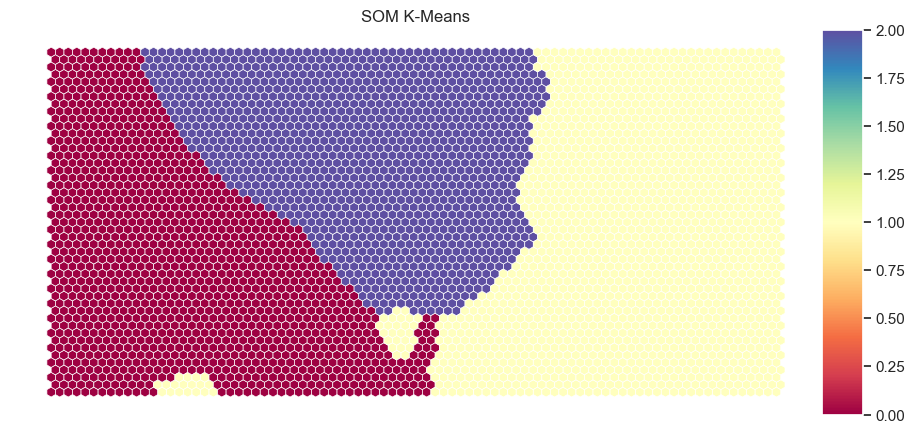

<Figure size 1100x500 with 0 Axes>

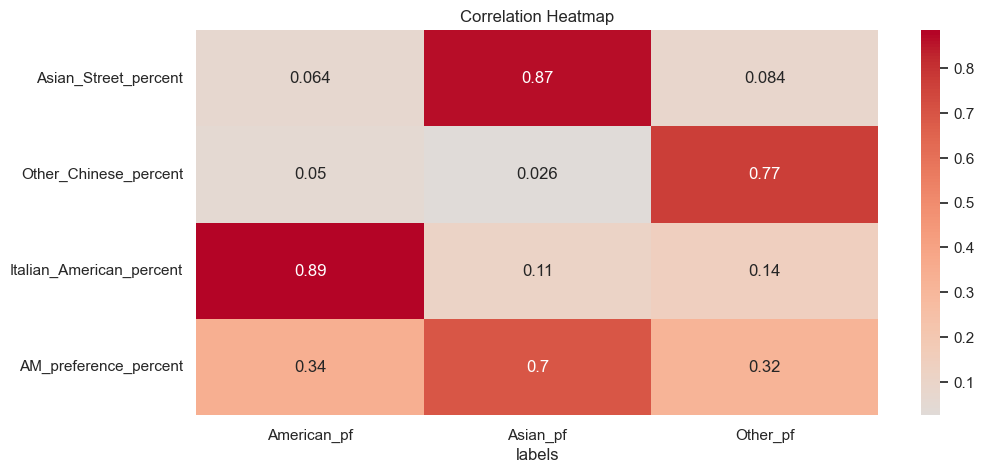

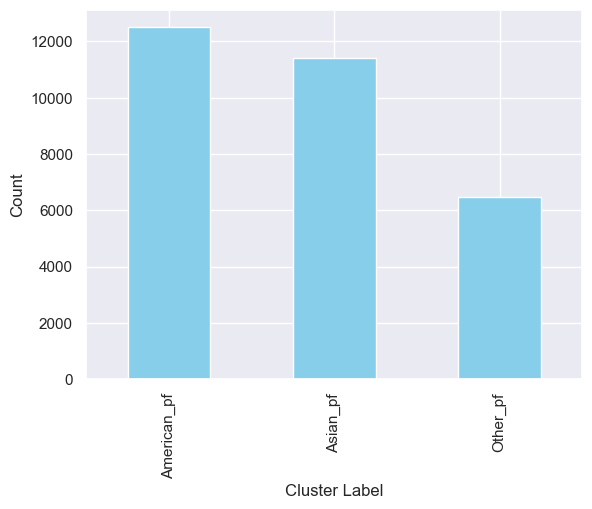

In [338]:

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42)

nodeclus_labels = kmeans.fit_predict(weights_flat)

 

kmeans_matrix = nodeclus_labels.reshape((M,N))

fig = plt.figure(figsize=(11,5))
colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(kmeans_matrix))
fig = plot_hexagons(sm, fig, 
                    colornorm,
                    kmeans_matrix,
                    label="SOM K-Means",
                    cmap=cm.Spectral,
                    )


nodes = weights_flat
df_nodes = pd.DataFrame(nodes, columns=preferences_cols)
df_nodes['label'] = nodeclus_labels

# shape df.shape[0], 2 dimension 
bmu_index = np.array([sm.winner(x) for x in df[preferences_cols].values])

som_final_labels = [kmeans_matrix[i[0]][i[1]] for i in bmu_index]
mapping = {0: 'Asian_pf', 1: 'American_pf', 2: 'Other_pf'}
som_final_labels = pd.Series(som_final_labels, name='labels', index=df.index)
som_final_labels = som_final_labels.map(mapping)

fig = plt.figure(figsize=(11,5))
df_concat = pd.concat((df[preferences_cols], pd.Series(som_final_labels, name='labels', index=df.index)), axis=1)
fig = plt.figure(figsize=(11,5))
sns.heatmap(df_concat.groupby("labels").mean().T, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

df_concat['labels'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.show()

In [339]:

silh = silhouette_score(df[preferences_cols], som_final_labels, metric='cosine', random_state=42)
silh

0.705527905916503

# Merging the Perspectives

In [340]:
columns_to_use = ['total_spent_log',
                'total_orders_log',
                'spend_per_vendor_log',
                "total_spent_chain_log", 
                "Asian_Street_percent",
                "Other_Chinese_percent",
                "Italian_American_percent",
                "AM_preference_percent",]

In [341]:
# Split variables into perspectives (example, requires critical thinking and domain knowledge)
value_cols = [
    'total_spent_log',
    'total_orders_log',
    'spend_per_vendor_log',
    "total_spent_chain_log"
]

preferences_cols = [
    "Asian_Street_percent",
    "Other_Chinese_percent",
    "Italian_American_percent",
    "AM_preference_percent" 
]

df_vb = df[value_cols].copy()
df_prf = df[preferences_cols].copy()

In [342]:
df["value_labels"] = km_labels
df["preferences_labels"] = som_final_labels

<Axes: xlabel='value_labels'>

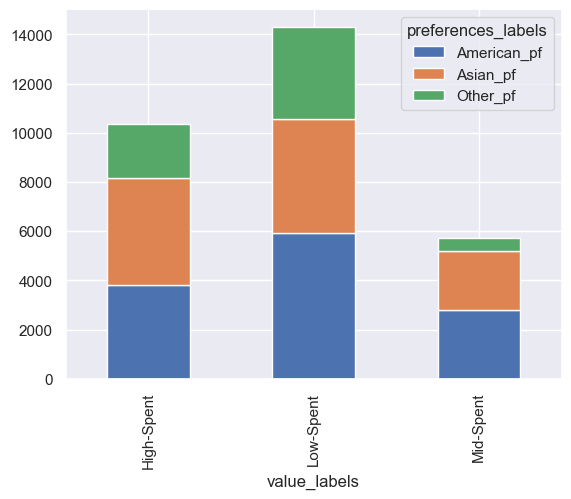

In [324]:
pd.crosstab(df['value_labels'],
            df['preferences_labels']).plot(kind='bar', stacked=True)

In [343]:
df_centroids = df.groupby(['value_labels', 'preferences_labels'])\
    [columns_to_use].mean()
df_centroids

total_spent_log  total_orders_log  \
value_labels preferences_labels                                      
High-Spent   American_pf                0.709623          0.516485   
             Asian_pf                   0.751548          0.447592   
             Other_pf                   0.672476          0.547505   
Low-Spent    American_pf                0.510055          0.161312   
             Asian_pf                   0.548633          0.142810   
             Other_pf                   0.480003          0.188093   
Mid-Spent    American_pf                0.554990          0.144705   
             Asian_pf                   0.602520          0.114359   
             Other_pf                   0.521489          0.101523   

                                 spend_per_vendor_log  total_spent_chain_log  \
value_labels preferences_labels                                                
High-Spent   American_pf                     0.539371               0.625362   
             Asian_pf                        0.605588               0.658722   
             Other_pf                        0.442119               0.617862   
Low-Spent    American_pf                     0.430498               0.434710   
             Asian_pf                        0.492610               0.473331   
             Other_pf                        0.365976               0.413345   
Mid-Spent    American_pf                     0.550780               0.000000   
             Asian_pf                        0.617129               0.000000   
             Other_pf                        0.514170               0.000000   

                                 Asian_Street_percent  Other_Chinese_percent  \
value_labels preferences_labels                                                
High-Spent   American_pf                     0.105127               0.090211   
             Asian_pf                        0.803782               0.035678   
             Other_pf                        0.131359               0.660542   
Low-Spent    American_pf                     0.057178               0.043818   
             Asian_pf                        0.877268               0.027862   
             Other_pf                        0.067876               0.815311   
Mid-Spent    American_pf                     0.023762               0.009840   
             Asian_pf                        0.957513               0.003216   
             Other_pf                        0.007634               0.922312   

                                 Italian_American_percent  \
value_labels preferences_labels                             
High-Spent   American_pf                         0.804662   
             Asian_pf                            0.160540   
             Other_pf                            0.208099   
Low-Spent    American_pf                         0.899005   
             Asian_pf                            0.094869   
             Other_pf                            0.116812   
Mid-Spent    American_pf                         0.966398   
             Asian_pf                            0.039271   
             Other_pf                            0.070054   

                                 AM_preference_percent  
value_labels preferences_labels                         
High-Spent   American_pf                      0.351360  
             Asian_pf                         0.749119  
             Other_pf                         0.342520  
Low-Spent    American_pf                      0.356690  
             Asian_pf                         0.652413  
             Other_pf                         0.309671  
Mid-Spent    American_pf                      0.284417  
             Asian_pf                         0.686075  
             Other_pf                         0.259280

In [344]:
range_clusters = range(2, 8)
linkage = ['ward', 'complete', 'average']
distance = ['euclidean', 'cosine', "manhattan"]
avg_silhouette = {}
for linkage_method in linkage:
    print(f"Linkage method: {linkage_method}")
    for dist in distance:
        print(f"Distance metric: {dist}")
        if (dist == "cosine" or dist == "manhattan") and linkage_method == "ward":
            continue
        avg_silhouette[(linkage_method, dist)] = []
        for nclus in range_clusters:

            aggclust = AgglomerativeClustering(n_clusters=nclus, linkage=linkage_method, metric=dist)
            cluster_labels = aggclust.fit_predict(df_centroids)

            silhouette_avg = silhouette_score(df_centroids, cluster_labels, metric=dist, random_state=42)
            avg_silhouette[(linkage_method, dist)].append(silhouette_avg)
            print(f"For n_clusters = {nclus}, the average silhouette_score is : {silhouette_avg}")
        print("-----------------------------------\n ")



Linkage method: ward
Distance metric: euclidean
For n_clusters = 2, the average silhouette_score is : 0.36567562260689856
For n_clusters = 3, the average silhouette_score is : 0.5119585054281669
For n_clusters = 4, the average silhouette_score is : 0.36828905565940695
For n_clusters = 5, the average silhouette_score is : 0.26071900059629544
For n_clusters = 6, the average silhouette_score is : 0.16250898324322463
For n_clusters = 7, the average silhouette_score is : 0.10643313288795696
-----------------------------------
 
Distance metric: cosine
Distance metric: manhattan
Linkage method: complete
Distance metric: euclidean
For n_clusters = 2, the average silhouette_score is : 0.36567562260689856
For n_clusters = 3, the average silhouette_score is : 0.5119585054281669
For n_clusters = 4, the average silhouette_score is : 0.36828905565940695
For n_clusters = 5, the average silhouette_score is : 0.26071900059629544
For n_clusters = 6, the average silhouette_score is : 0.16250898324322463

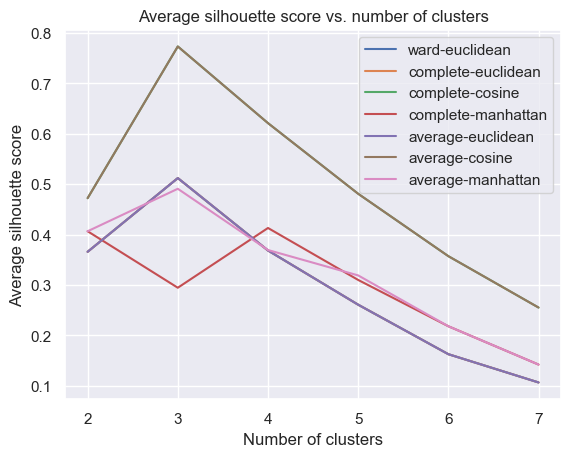

In [345]:
for key, val in avg_silhouette.items():
    sns.lineplot(x=range_clusters, y=val, label=f"{key[0]}-{key[1]}")
plt.xlabel("Number of clusters")
plt.ylabel("Average silhouette score")
plt.title("Average silhouette score vs. number of clusters")
plt.legend()
plt.show()

In [346]:
linkage = 'complete'
hclust = AgglomerativeClustering(
    linkage=linkage, 
    metric='manhattan', 
    distance_threshold=0, 
    n_clusters=None
)

hclust_labels = hclust.fit_predict(df_centroids)

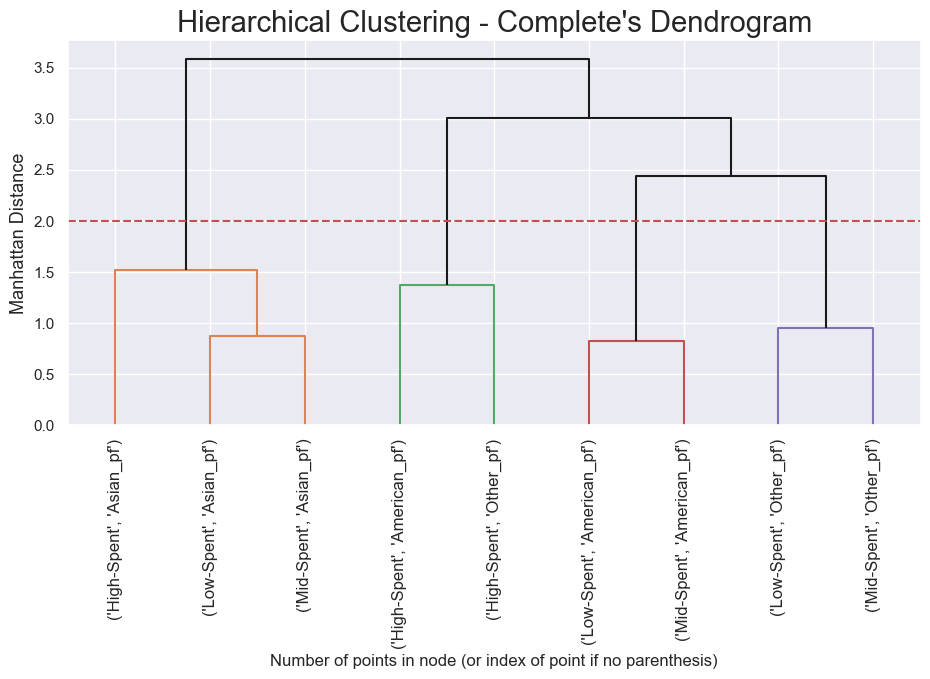

In [347]:
# create the counts of samples under each node (number of points being merged)
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

# At the i-th iteration, children[i][0] and children[i][1] are merged to form node n_samples + i
for i, merge in enumerate(hclust.children_):
    # track the number of observations in the current cluster being formed
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            # If this is True, then we are merging an observation
            current_count += 1  # leaf node
        else:
            # Otherwise, we are merging a previously formed cluster
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

# the counts indicate the number of points being merged (dendrogram's x-axis)
linkage_matrix = np.column_stack(
    [hclust.children_, hclust.distances_, counts]
).astype(float)

# Plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
# The Dendrogram parameters need to be tuned

y_threshold = 2
# y_threshold = 3.3

dendrogram(linkage_matrix, 
           truncate_mode='level', 
           labels=df_centroids.index, p=5, 
           color_threshold=y_threshold, 
           above_threshold_color='k')

plt.hlines(y_threshold, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering - {linkage.title()}\'s Dendrogram', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.xticks(rotation=90)
plt.ylabel(f'Manhattan Distance', fontsize=13)
plt.show()

In [348]:
hclust = AgglomerativeClustering(
    linkage='complete', 
    metric='manhattan', 
    n_clusters=4
)
hclust_labels = hclust.fit_predict(df_centroids)
df_centroids['hclust_labels'] = hclust_labels

df_centroids 

total_spent_log  total_orders_log  \
value_labels preferences_labels                                      
High-Spent   American_pf                0.709623          0.516485   
             Asian_pf                   0.751548          0.447592   
             Other_pf                   0.672476          0.547505   
Low-Spent    American_pf                0.510055          0.161312   
             Asian_pf                   0.548633          0.142810   
             Other_pf                   0.480003          0.188093   
Mid-Spent    American_pf                0.554990          0.144705   
             Asian_pf                   0.602520          0.114359   
             Other_pf                   0.521489          0.101523   

                                 spend_per_vendor_log  total_spent_chain_log  \
value_labels preferences_labels                                                
High-Spent   American_pf                     0.539371               0.625362   
             Asian_pf                        0.605588               0.658722   
             Other_pf                        0.442119               0.617862   
Low-Spent    American_pf                     0.430498               0.434710   
             Asian_pf                        0.492610               0.473331   
             Other_pf                        0.365976               0.413345   
Mid-Spent    American_pf                     0.550780               0.000000   
             Asian_pf                        0.617129               0.000000   
             Other_pf                        0.514170               0.000000   

                                 Asian_Street_percent  Other_Chinese_percent  \
value_labels preferences_labels                                                
High-Spent   American_pf                     0.105127               0.090211   
             Asian_pf                        0.803782               0.035678   
             Other_pf                        0.131359               0.660542   
Low-Spent    American_pf                     0.057178               0.043818   
             Asian_pf                        0.877268               0.027862   
             Other_pf                        0.067876               0.815311   
Mid-Spent    American_pf                     0.023762               0.009840   
             Asian_pf                        0.957513               0.003216   
             Other_pf                        0.007634               0.922312   

                                 Italian_American_percent  \
value_labels preferences_labels                             
High-Spent   American_pf                         0.804662   
             Asian_pf                            0.160540   
             Other_pf                            0.208099   
Low-Spent    American_pf                         0.899005   
             Asian_pf                            0.094869   
             Other_pf                            0.116812   
Mid-Spent    American_pf                         0.966398   
             Asian_pf                            0.039271   
             Other_pf                            0.070054   

                                 AM_preference_percent  hclust_labels  
value_labels preferences_labels                                        
High-Spent   American_pf                      0.351360              2  
             Asian_pf                         0.749119              0  
             Other_pf                         0.342520              2  
Low-Spent    American_pf                      0.356690              3  
             Asian_pf                         0.652413              0  
             Other_pf                         0.309671              1  
Mid-Spent    American_pf                      0.284417              3  
             Asian_pf                         0.686075              0  
             Other_pf                         0.259280              1

In [349]:
cluster_mapper = df_centroids['hclust_labels'].to_dict()
cluster_mapper

{('High-Spent', 'American_pf'): 2,
 ('High-Spent', 'Asian_pf'): 0,
 ('High-Spent', 'Other_pf'): 2,
 ('Low-Spent', 'American_pf'): 3,
 ('Low-Spent', 'Asian_pf'): 0,
 ('Low-Spent', 'Other_pf'): 1,
 ('Mid-Spent', 'American_pf'): 3,
 ('Mid-Spent', 'Asian_pf'): 0,
 ('Mid-Spent', 'Other_pf'): 1}

In [350]:
reversed_data = {}
for key, value in cluster_mapper.items():
    if value not in reversed_data:
        reversed_data[value] = []  # Create list if value doesn't exist
    reversed_data[value].append(key)  # Append keys to the value

# Display the result
for value, keys in reversed_data.items():
    print(f"{value}: {keys}")

2: [('High-Spent', 'American_pf'), ('High-Spent', 'Other_pf')]
0: [('High-Spent', 'Asian_pf'), ('Low-Spent', 'Asian_pf'), ('Mid-Spent', 'Asian_pf')]
3: [('Low-Spent', 'American_pf'), ('Mid-Spent', 'American_pf')]
1: [('Low-Spent', 'Other_pf'), ('Mid-Spent', 'Other_pf')]


In [351]:
df_ = df.copy()

df_['merged_labels'] = df_.apply(
    lambda row: cluster_mapper[
        (row['value_labels'], row['preferences_labels'])
    ], axis=1
)

df_ 

,customer_id,customer_age,vendor_count,product_count,is_chain,first_order,last_order,CUI_American,CUI_Asian,CUI_Beverages,...,last_promo_NO PROMO,payment_method_CARD,payment_method_CASH,payment_method_DIGI,customer_activity_Active,customer_activity_Churning,customer_activity_Recent,value_labels,preferences_labels,merged_labels
0,1b8f824d5e,18,2,5,1,0.0,0.011111,0.000000,0.000000,0.000000,...,False,False,False,True,False,True,False,Low-Spent,American_pf,3
1,5d272b9dcb,17,2,2,2,0.0,0.011111,0.055318,0.022287,0.000000,...,False,False,False,True,False,True,False,Low-Spent,American_pf,3
2,f6d1b2ba63,38,1,2,2,0.0,0.011111,0.039698,0.000000,0.000000,...,False,False,True,False,False,True,False,Low-Spent,American_pf,3
3,180c632ed8,25,2,3,1,0.0,0.022222,0.000000,0.047782,0.000000,...,False,False,False,True,False,True,False,Low-Spent,American_pf,3
4,4eb37a6705,20,2,5,0,0.0,0.022222,0.062869,0.142543,0.000000,...,True,False,False,True,False,True,False,Mid-Spent,Asian_pf,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30400,f4e366c281,30,1,1,1,0.0,0.000000,0.000000,0.000000,0.093748,...,False,False,False,True,False,True,False,Low-Spent,Asian_pf,0
30401,f6b6709018,24,1,1,0,0.0,0.000000,0.077843,0.000000,0.000000,...,False,False,False,True,False,True,False,Mid-Spent,American_pf,3
30402,f74ad8ce3f,24,1,1,1,0.0,0.000000,0.000000,0.000000,0.000000,...,True,False,False,True,False,True,False,Low-Spent,Asian_pf,0
30403,f7b19c0241,34,1,1,0,0.0,0.000000,0.000000,0.041957,0.000000,...,False,False,False,True,False,True,False,Mid-Spent,Asian_pf,0


In [352]:
df_.groupby('merged_labels').mean(numeric_only=True)[columns_to_use]

,total_spent_log,total_orders_log,spend_per_vendor_log,total_spent_chain_log,Asian_Street_percent,Other_Chinese_percent,Italian_American_percent,AM_preference_percent
merged_labels,,,,,,,,
0,0.637569,0.253426,0.561973,0.444865,0.866006,0.025677,0.108316,0.696474
1,0.485375,0.176883,0.385164,0.359824,0.060076,0.829166,0.110758,0.303146
2,0.696041,0.527827,0.503812,0.622620,0.114718,0.298745,0.586536,0.348128
3,0.524429,0.156000,0.468974,0.295653,0.046489,0.032949,0.920563,0.333571


In [354]:
# Setting df to have the final valeu, preferences and merged clusters
# df = df_.copy()
df = df_.copy()

## Cluster Analysis

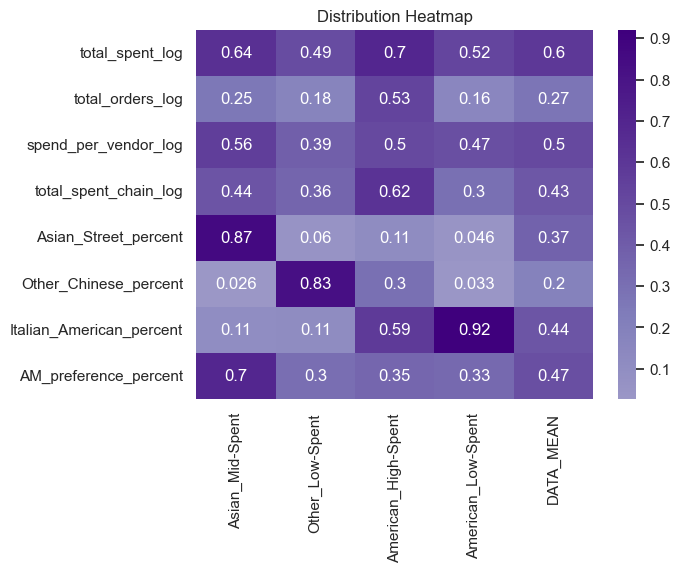

In [356]:
df[columns_to_use+["merged_labels"]]
df[columns_to_use].mean().T
data_mean = pd.DataFrame(df[columns_to_use].mean().T, columns=["DATA_MEAN"])

df_all = pd.concat([df[columns_to_use+["merged_labels"]].groupby("merged_labels").mean().T, data_mean], axis=1)
df_all
df_all.rename(columns={0: "Asian_Mid-Spent", 1: "Other_Low-Spent", 2: "American_High-Spent", 3: "American_Low-Spent"}, inplace=True)
df_all

sns.heatmap(df_all, annot=True, cmap="Purples", center=0)
plt.title("Distribution Heatmap")
plt.xticks(rotation=90)
plt.show()


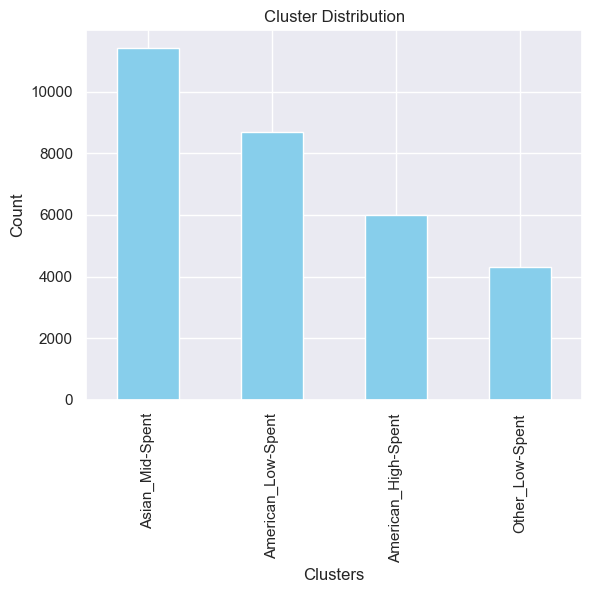

In [357]:
mapping = {0: "Asian_Mid-Spent", 1: "Other_Low-Spent", 2: "American_High-Spent", 3: "American_Low-Spent"}
df['merged_labels'] = df['merged_labels'].map(mapping)

df["merged_labels"].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Clusters')
plt.ylabel('Count')
plt.title('Cluster Distribution')
plt.show()

In [ ]:
df["merged_labels"].value_counts(normalize=True).plot(kind='bar', color='skyblue')
plt.xlabel('Clusters')
plt.ylabel('Count')
plt.title('Cluster Distribution')
plt.show()

In [360]:
def cluster_profiles(df, label_columns, figsize, 
                     cmap="tab10",
                     compare_titles=None):
    """
    Pass df with labels columns of one or multiple clustering labels. 
    Then specify this label columns to perform the cluster profile according to them.
    """
    
    if compare_titles == None:
        compare_titles = [""]*len(label_columns)
        
    fig, axes = plt.subplots(nrows=len(label_columns), 
                             ncols=2, 
                             figsize=figsize, 
                             constrained_layout=True,
                             squeeze=False)
    i = 0
    for ax, label, titl in zip(axes, label_columns, compare_titles):
        # Filtering df
        drop_cols = [i for i in label_columns if i!=label]
        dfax = df.drop(drop_cols, axis=1)
        
        # Getting the cluster centroids and counts
        centroids = dfax.groupby(by=label, as_index=False).mean()
        counts = dfax.groupby(by=label, as_index=False).count().iloc[:,[0,1]]
        counts.columns = [label, "counts"]
        
        # Setting Data
        pd.plotting.parallel_coordinates(centroids, 
                                            label, 
                                            color = sns.color_palette(cmap),
                                            ax=ax[0])



        sns.barplot(x=label, 
                    hue=label,
                    y="counts", 
                    data=counts, 
                    ax=ax[1], 
                    palette=sns.color_palette(cmap),
                    legend=False
                    )

        #Setting Layout
        handles, _ = ax[0].get_legend_handles_labels()
        if i == 0:
            cluster_labels = ["High-Spent", "Low-Spent", "Mid-Spent"]
        elif i == 1:
            cluster_labels = ["American_pf", "Asian-pf", "Other_pf"]
        else:
            cluster_labels = ["American_High-Spent", "American_Low-Spent", "Asian_Mid-Spent", "Other_Low-Spent"]
        i += 1
        ax[0].annotate(text=titl, xy=(0.95,1.1), xycoords='axes fraction', fontsize=13, fontweight = 'heavy') 
        ax[0].axhline(color="black", linestyle="--")
        ax[0].set_title("Cluster Means - {} Clusters".format(len(handles)), fontsize=13)
        ax[0].set_xticklabels(ax[0].get_xticklabels(), 
                              rotation=40,
                              ha='right'
                              )
        
        ax[0].legend(handles, cluster_labels,
                     loc='center left', bbox_to_anchor=(1, 0.5), title=label
                     ) # Adaptable to number of clusters
        
        ax[1].set_xticks([i for i in range(len(handles))])
        ax[1].set_xticklabels(cluster_labels)
        ax[1].set_xlabel("")
        ax[1].set_ylabel("Absolute Frequency")
        ax[1].set_title("Cluster Sizes - {} Clusters".format(len(handles)), fontsize=13)
        
        
    
    # plt.subplots_adjust(hspace=0.4, top=0.90)
    plt.suptitle("Cluster Simple Profiling", fontsize=23)
    plt.show()

C:\Users\gaspa\AppData\Local\Temp\ipykernel_26272\223929423.py:36: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(x=label,
C:\Users\gaspa\AppData\Local\Temp\ipykernel_26272\223929423.py:36: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(x=label,
C:\Users\gaspa\AppData\Local\Temp\ipykernel_26272\223929423.py:36: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(x=label,


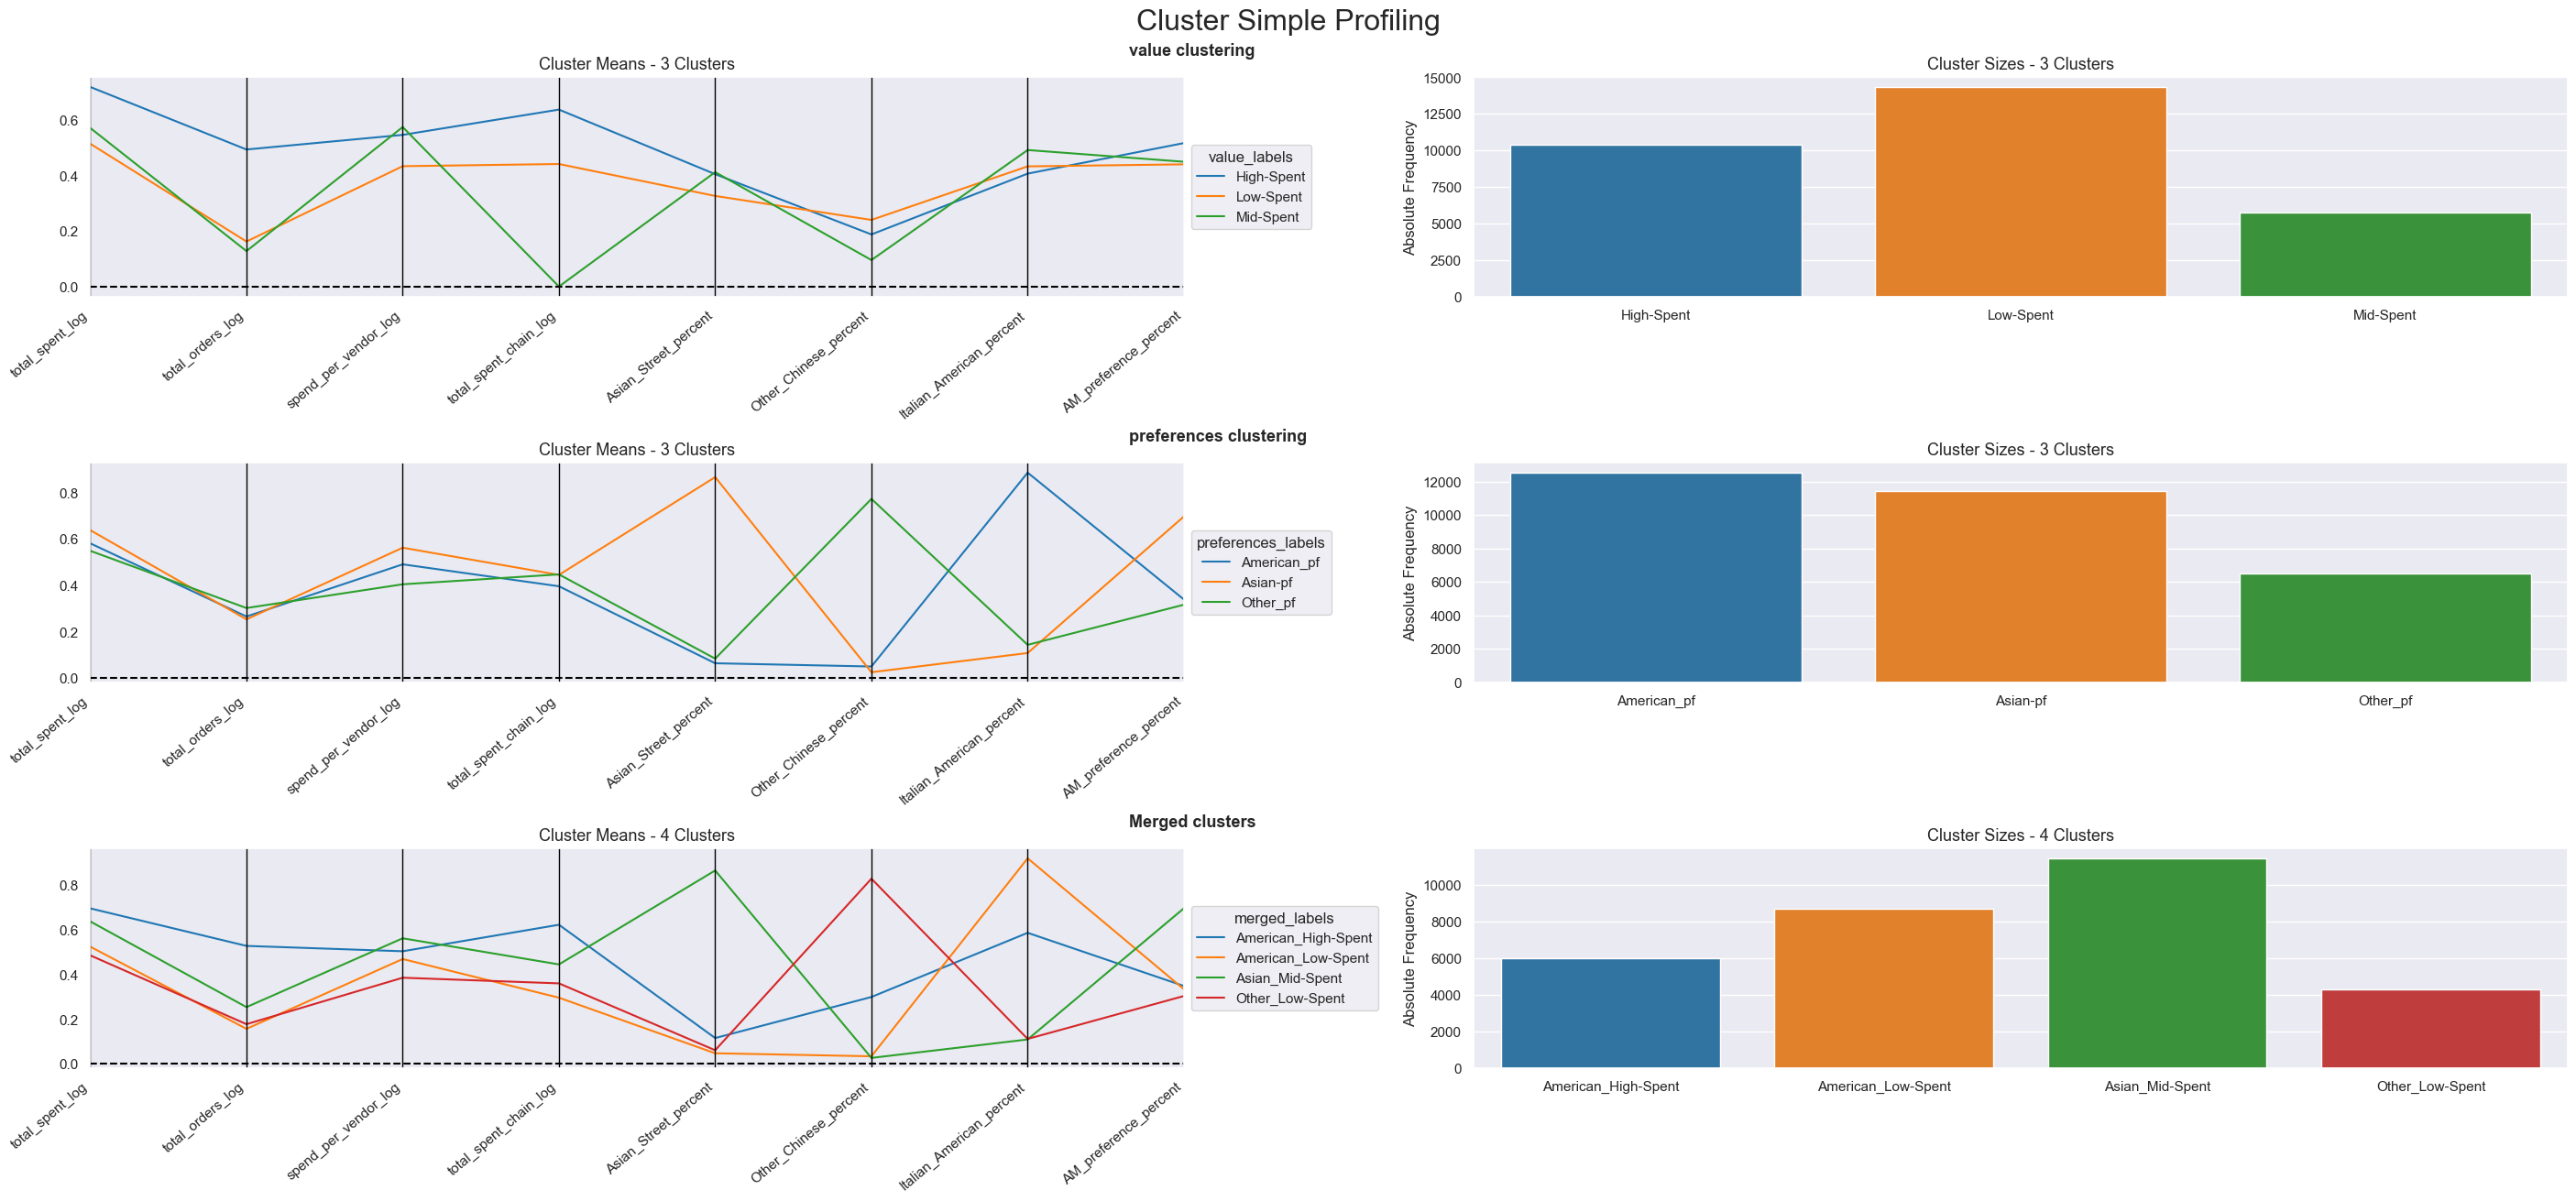

In [361]:
# Profilling each cluster (product, behavior, merged)
cluster_profiles(
    df = df[columns_to_use + ['value_labels', 'preferences_labels', 'merged_labels']], 
    label_columns = ['value_labels', 'preferences_labels', 'merged_labels'], 
    figsize = (28, 13), 
    compare_titles = ["value clustering", "preferences clustering", "Merged clusters"]
)

## Profiling with categorical features

In [362]:
new_cat_cols = [['customer_region_2370',
 'customer_region_4660',
 'customer_region_8670',
 'last_promo_DELIVERY',
 'last_promo_DISCOUNT',
 'last_promo_FREEBIE',
 'last_promo_NO PROMO',
 'payment_method_CARD',
 'payment_method_CASH',
 'payment_method_DIGI',
 'customer_activity_Active',
 'customer_activity_Churning',
 'customer_activity_Recent']]

### Region

In [364]:
region = df[['merged_labels',
            'customer_region_2370',
            'customer_region_4660',
            'customer_region_8670']].groupby(['merged_labels']).sum()


conditions = [
    df['customer_region_2370'] == 1,
    df['customer_region_4660'] == 1,
    df['customer_region_8670'] == 1,
]
choices = ['2370', '4660', '8670']

df['region_name'] = np.select(conditions, choices, default='Unknown')

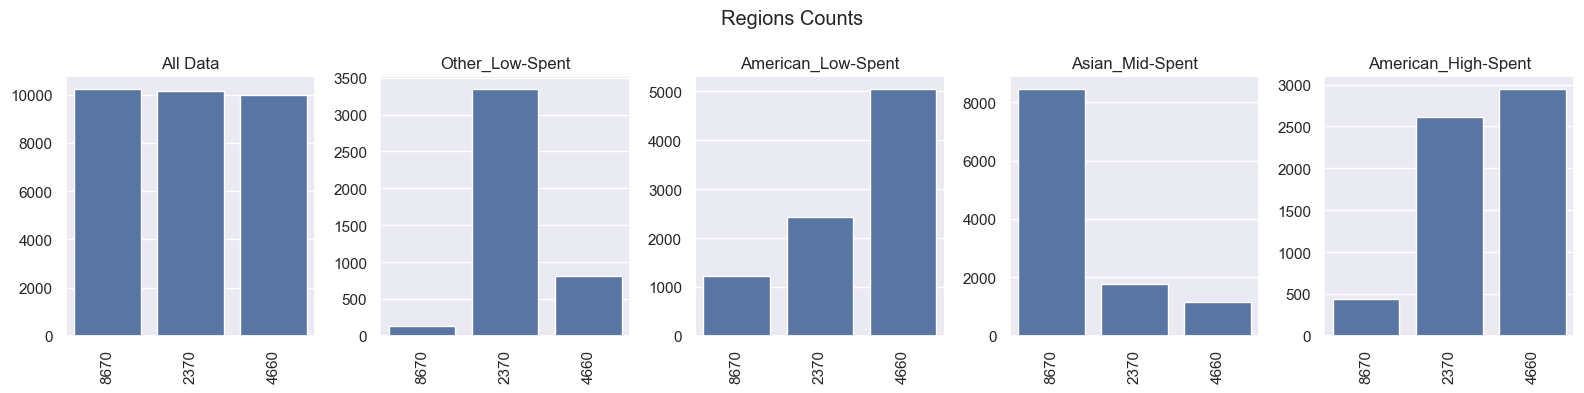

In [370]:
fig, axes = plt.subplots(
    1, 
    df['merged_labels'].nunique() + 1,  # Add an extra ax for population countplot
    figsize=(16, 4),
    tight_layout=True,
)

for i, ax in enumerate(axes.flatten()):
    if i == 0:
        sns.countplot(
            data=df, 
            x='region_name', 
            order=df['region_name'].value_counts().index,
            ax=ax
        )
        ax.set_title("All Data")
    else:
        lb = ["Other_Low-Spent", "American_Low-Spent", "Asian_Mid-Spent",  "American_High-Spent"]    
        sns.countplot(
            data=df[df['merged_labels'] == lb[i-1]], 
            x='region_name', 
            order=df['region_name'].value_counts().index,
            ax=ax
        )
        ax.set_title(f"{lb[i-1]}")
    
    ax.tick_params(axis="x", labelrotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Regions Counts")
plt.show()

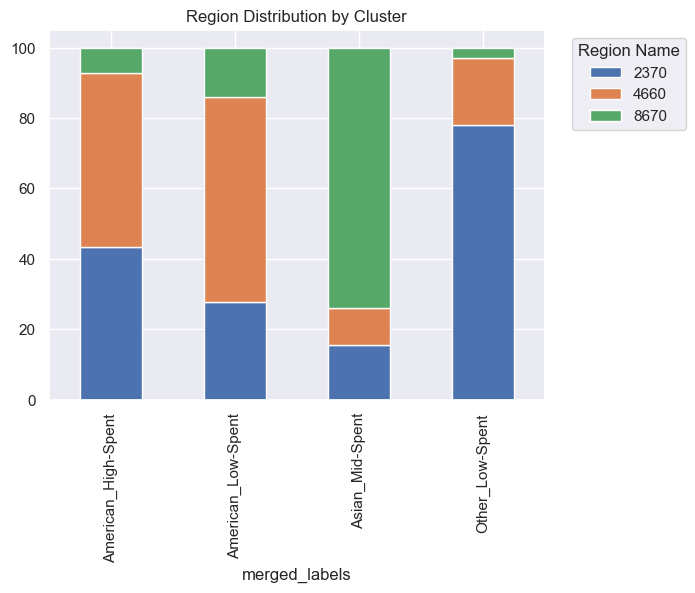

In [366]:
df_cl_ed = df.groupby([
    "merged_labels", 
    "region_name",
    ])['region_name'].size().unstack()

df_cl_ed_pct = df_cl_ed.copy()
for i in df['region_name'].unique():
    df_cl_ed_pct[i] = 100*df_cl_ed_pct[i]/df['merged_labels'].value_counts().sort_index().values

df_cl_ed_pct.plot.bar(stacked=True)
plt.legend(title="Region Name", loc='upper right', bbox_to_anchor=(1.3, 1))
plt.title("Region Distribution by Cluster")
plt.show()

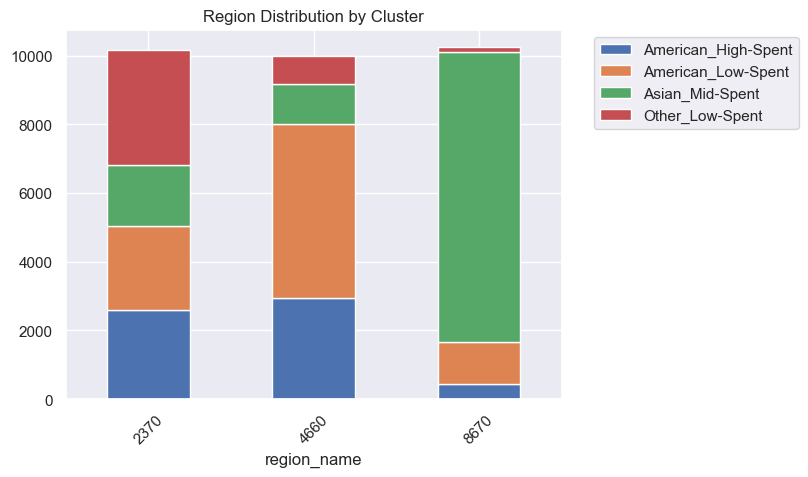

In [367]:
pd.crosstab(df["region_name"], df["merged_labels"]).plot(kind='bar', stacked=True)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title("Region Distribution by Cluster")
plt.show()



### Promotion

In [371]:
promotion = df[['merged_labels',
            'last_promo_DELIVERY',
            'last_promo_DISCOUNT',
            'last_promo_FREEBIE',
            'last_promo_NO PROMO']].groupby(['merged_labels']).sum()


conditions = [
    df['last_promo_DELIVERY'] == 1,
    df['last_promo_DISCOUNT'] == 1,
    df['last_promo_FREEBIE'] == 1,
    df['last_promo_NO PROMO'] == 1,
]
choices = ['DELIVERY', 'DISCOUNT', 'FREEBIE', 'NO PROMO']

df['promotion_type'] = np.select(conditions, choices, default='Unknown')

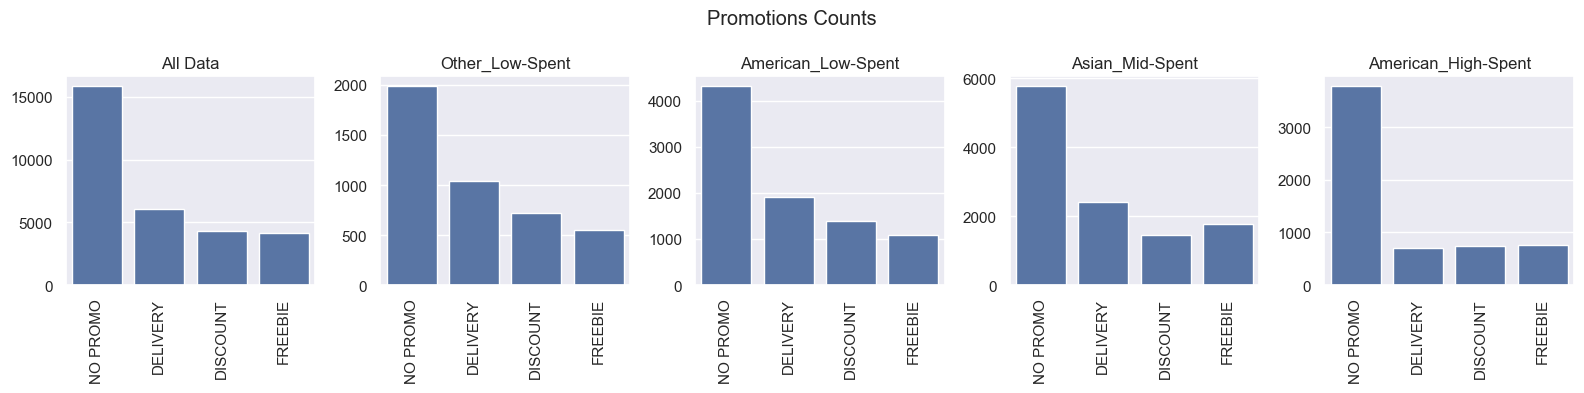

In [372]:
fig, axes = plt.subplots(
    1, 
    df['merged_labels'].nunique() + 1,  # Add an extra ax for population countplot
    figsize=(16, 4),
    tight_layout=True,
)

for i, ax in enumerate(axes.flatten()):
    if i == 0:
        sns.countplot(
            data=df, 
            x='promotion_type', 
            order=df['promotion_type'].value_counts().index,
            ax=ax
        )
        ax.set_title("All Data")
    else:
        lb = ["Other_Low-Spent", "American_Low-Spent", "Asian_Mid-Spent",  "American_High-Spent"]    
        sns.countplot(
            data=df[df['merged_labels'] == lb[i-1]], 
            x='promotion_type', 
            order=df['promotion_type'].value_counts().index,
            ax=ax
        )
        ax.set_title(f"{lb[i-1]}")
    
    ax.tick_params(axis="x", labelrotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Promotions Counts")
plt.show()

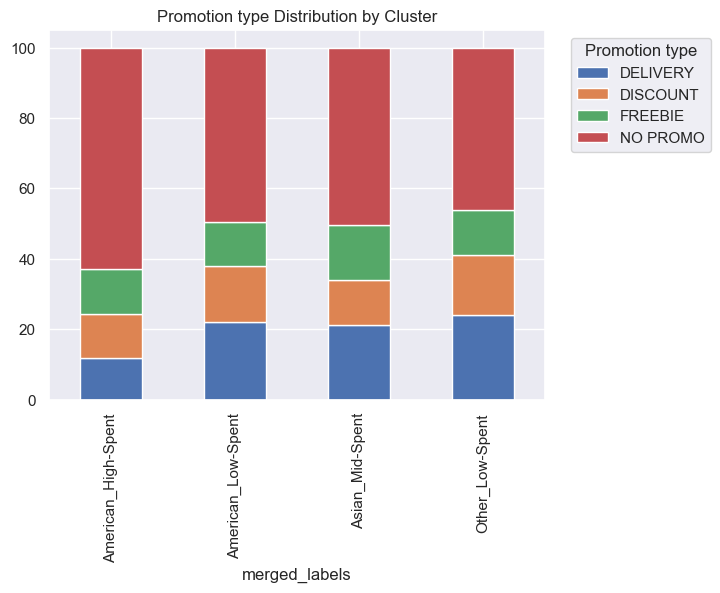

In [373]:
df_cl_ed = df.groupby([
    "merged_labels", 
    "promotion_type",
    ])['promotion_type'].size().unstack()

df_cl_ed_pct = df_cl_ed.copy()
for i in df['promotion_type'].unique():
    df_cl_ed_pct[i] = 100*df_cl_ed_pct[i]/df['merged_labels'].value_counts().sort_index().values

df_cl_ed_pct.plot.bar(stacked=True)
plt.legend(title="Promotion type", bbox_to_anchor=(1.35, 1), loc='upper right')
plt.title("Promotion type Distribution by Cluster")
plt.show()

### Customer Activity

In [374]:
recency = df[['merged_labels',
             'customer_activity_Active',
             'customer_activity_Churning',
             'customer_activity_Recent']].groupby(['merged_labels']).sum()

conditions = [
    df['customer_activity_Active'] == 1,
    df['customer_activity_Churning'] == 1,
    df['customer_activity_Recent'] == 1,
]
choices = ['ACTIVE', 'CHURNING', 'RECENT']

df['activity_type'] = np.select(conditions, choices, default='Unknown')

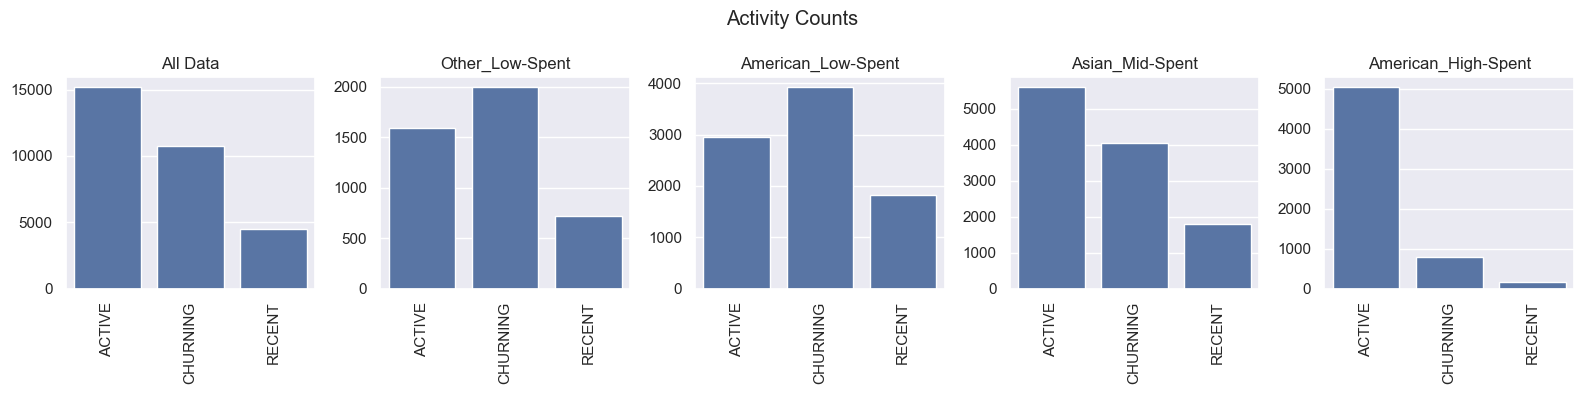

In [375]:
fig, axes = plt.subplots(
    1, 
    df['merged_labels'].nunique() + 1,  # Add an extra ax for population countplot
    figsize=(16, 4),
    tight_layout=True,
)

for i, ax in enumerate(axes.flatten()):
    if i == 0:
        sns.countplot(
            data=df, 
            x='activity_type', 
            order=df['activity_type'].value_counts().index,
            ax=ax
        )
        ax.set_title("All Data")
    else:
        lb = ["Other_Low-Spent", "American_Low-Spent", "Asian_Mid-Spent",  "American_High-Spent"]
        sns.countplot(
            data=df[df['merged_labels'] == lb[i-1]], 
            x='activity_type', 
            order=df['activity_type'].value_counts().index,
            ax=ax
        )
        ax.set_title(f"{lb[i-1]}")
    
    ax.tick_params(axis="x", labelrotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Activity Counts")
plt.show()

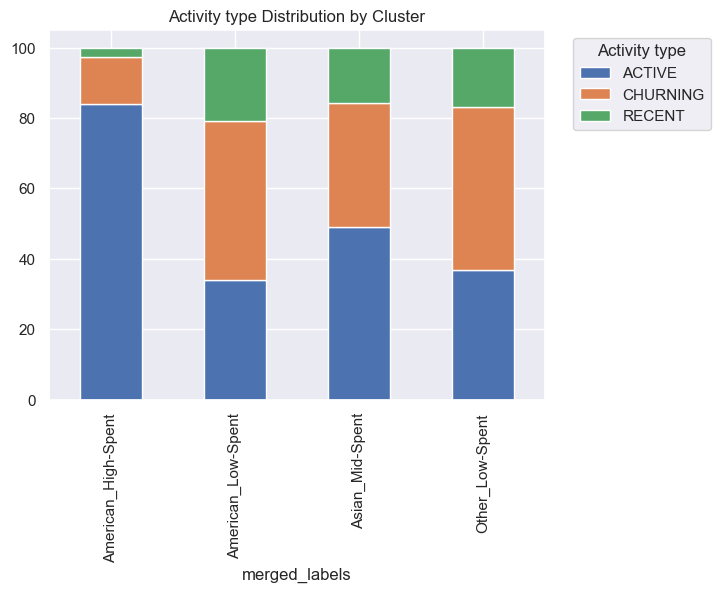

In [376]:
df_cl_ed = df.groupby([
    "merged_labels", 
    "activity_type",
    ])['activity_type'].size().unstack()

df_cl_ed_pct = df_cl_ed.copy()
for i in df['activity_type'].unique():
    df_cl_ed_pct[i] = 100*df_cl_ed_pct[i]/df['merged_labels'].value_counts().sort_index().values

df_cl_ed_pct.plot.bar(stacked=True)
plt.legend(title="Activity type", bbox_to_anchor=(1.35, 1), loc='upper right')
plt.title("Activity type Distribution by Cluster")
plt.show()


# Profilling for unused numerical features 

In [378]:
unused_cols = ["customer_age", "vendor_count", "product_count", "products_per_vendor", "product_engagement", "is_chain", "percentage_chain", "avg_order_value", "customer_lifetime", "weekly_order_frequency", "weekend_orders_percent", "total_spent", "total_orders"]

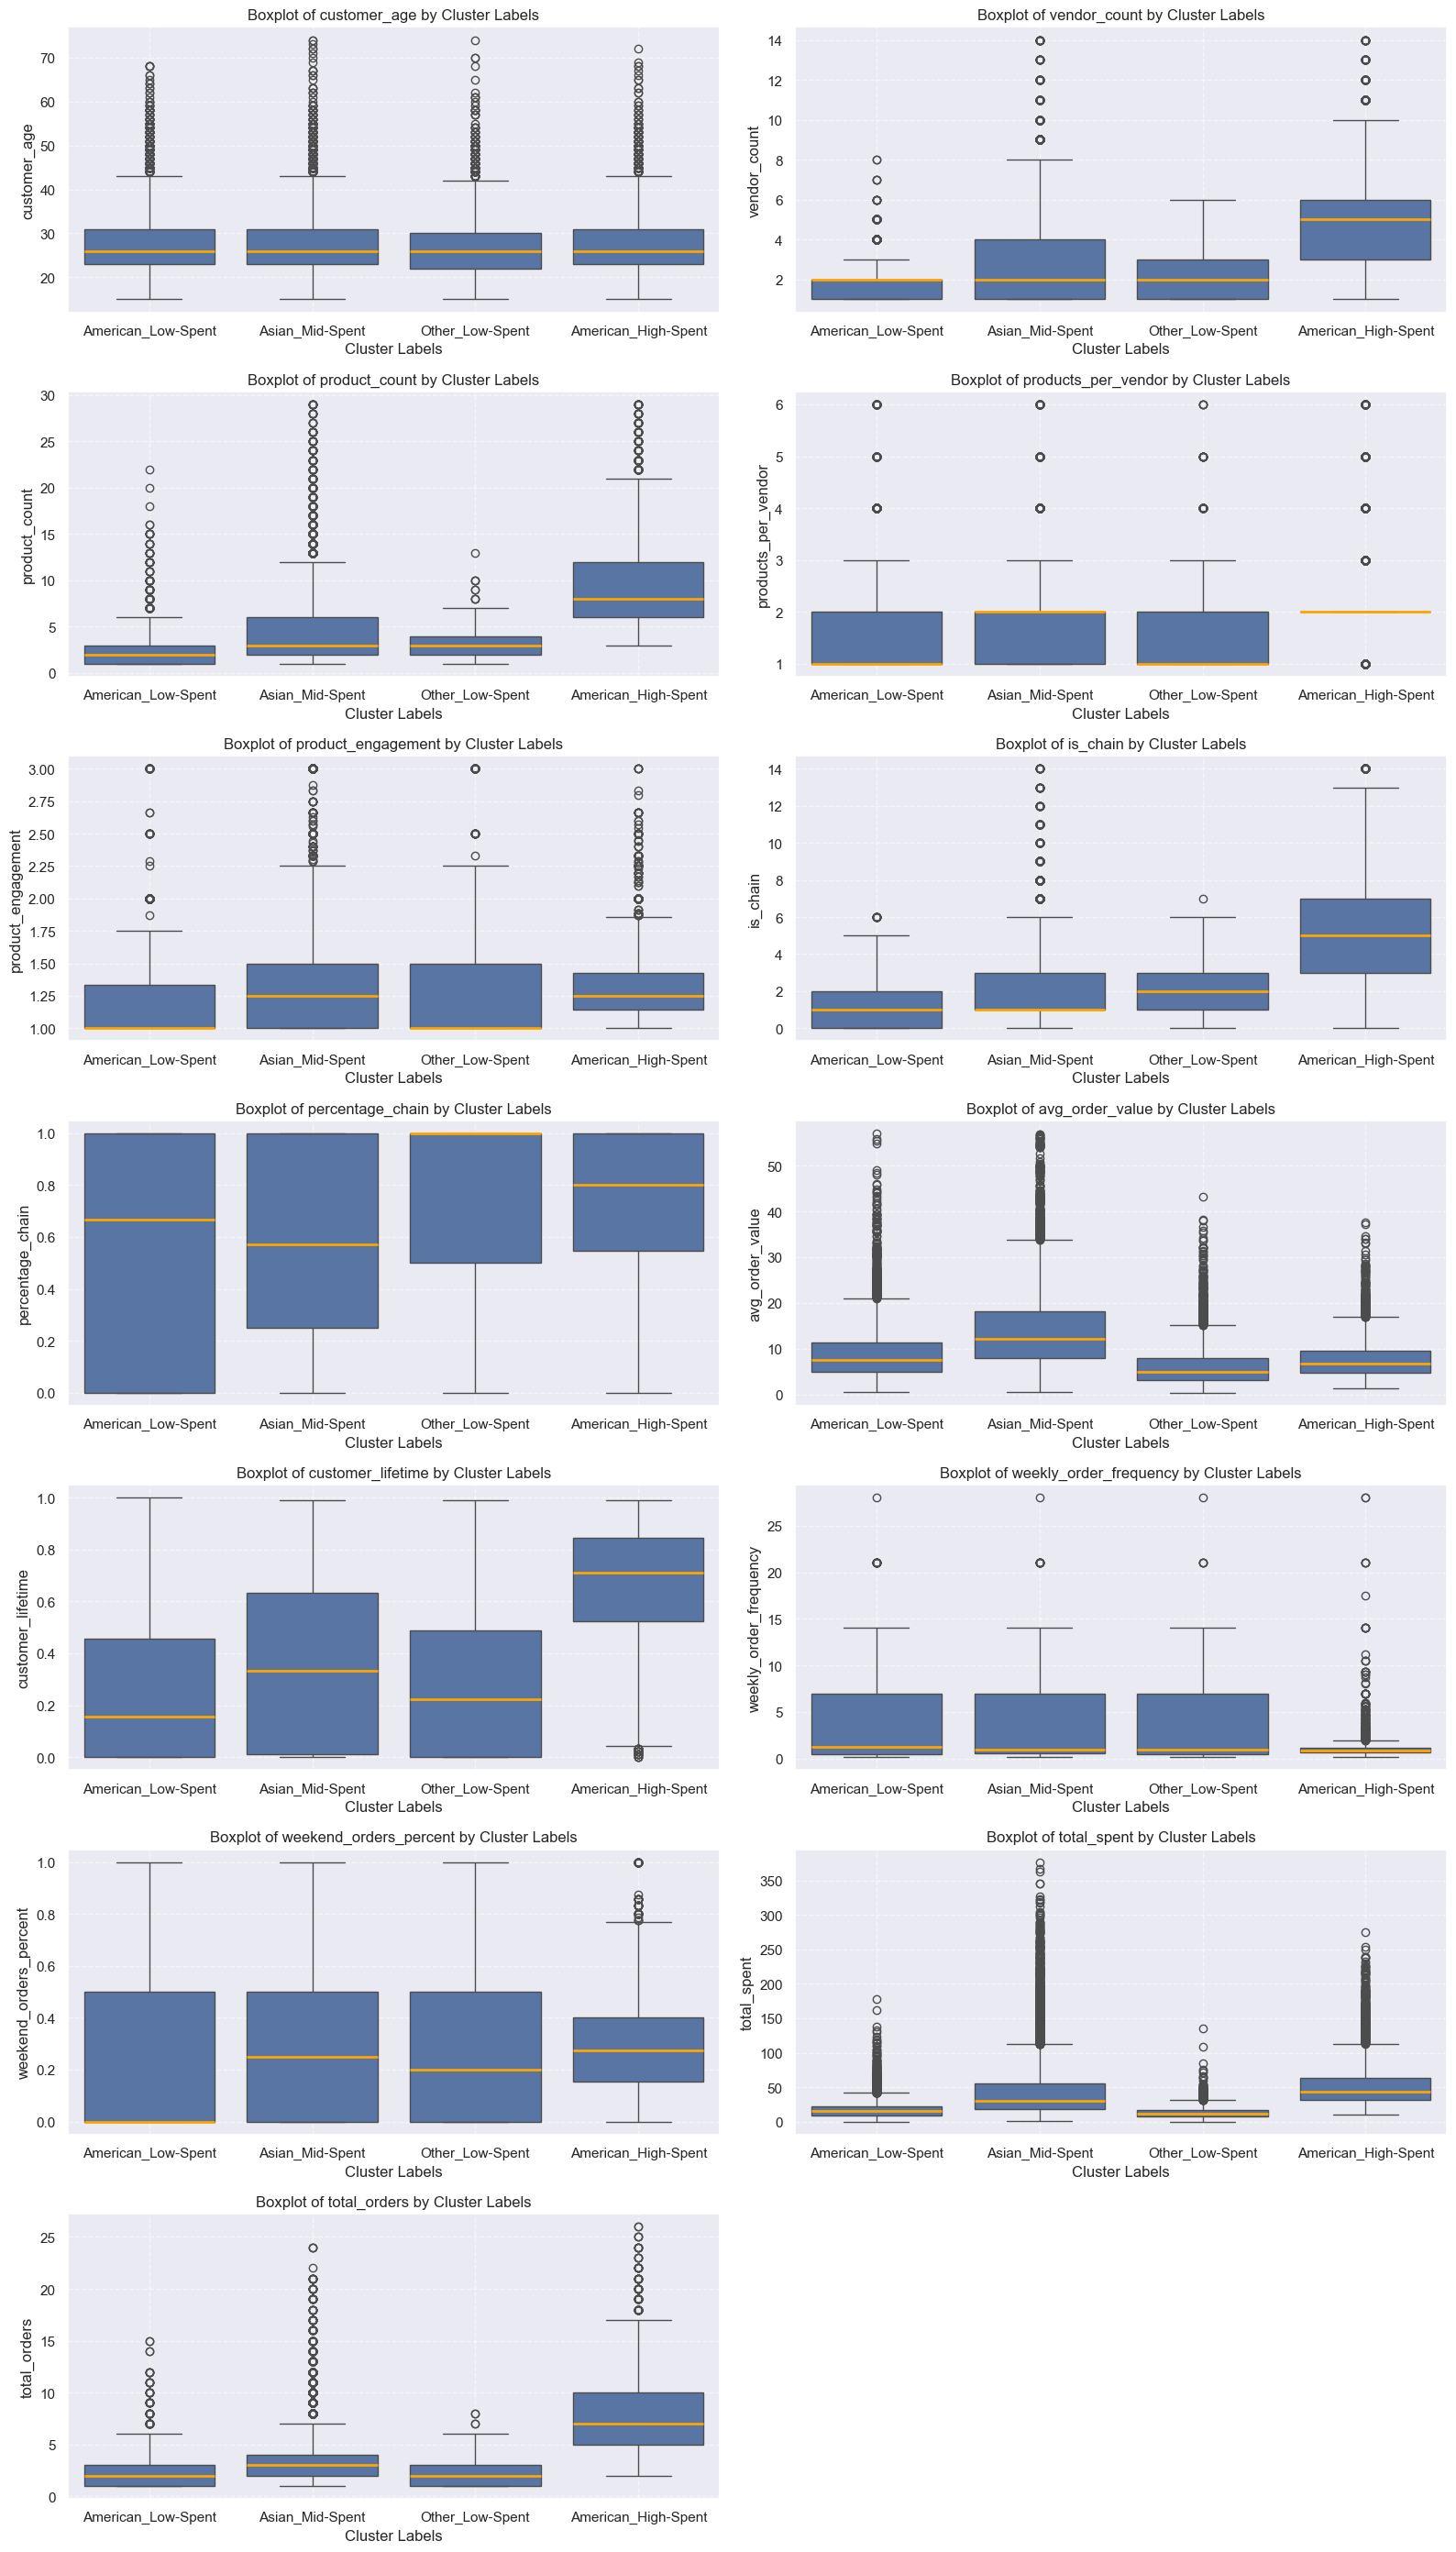

In [379]:
n_cols = 2
n_rows = math.ceil(len(unused_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows)) 
axes = axes.flatten()  

for i, col in enumerate(unused_cols):
    sns.boxplot(data=df, x='merged_labels', y=col, ax=axes[i]) 
    
    for _, line in enumerate(axes[i].lines[4::6]):
        line.set_color("orange")
        line.set_linewidth(2)
    axes[i].set_title(f"Boxplot of {col} by Cluster Labels") 
    axes[i].set_xlabel("Cluster Labels") 
    axes[i].set_ylabel(col)
    axes[i].grid(True, linestyle='--', alpha=0.6) 
    
for i in range(len(unused_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Cluster Visualization

In [291]:
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier, export_graphviz


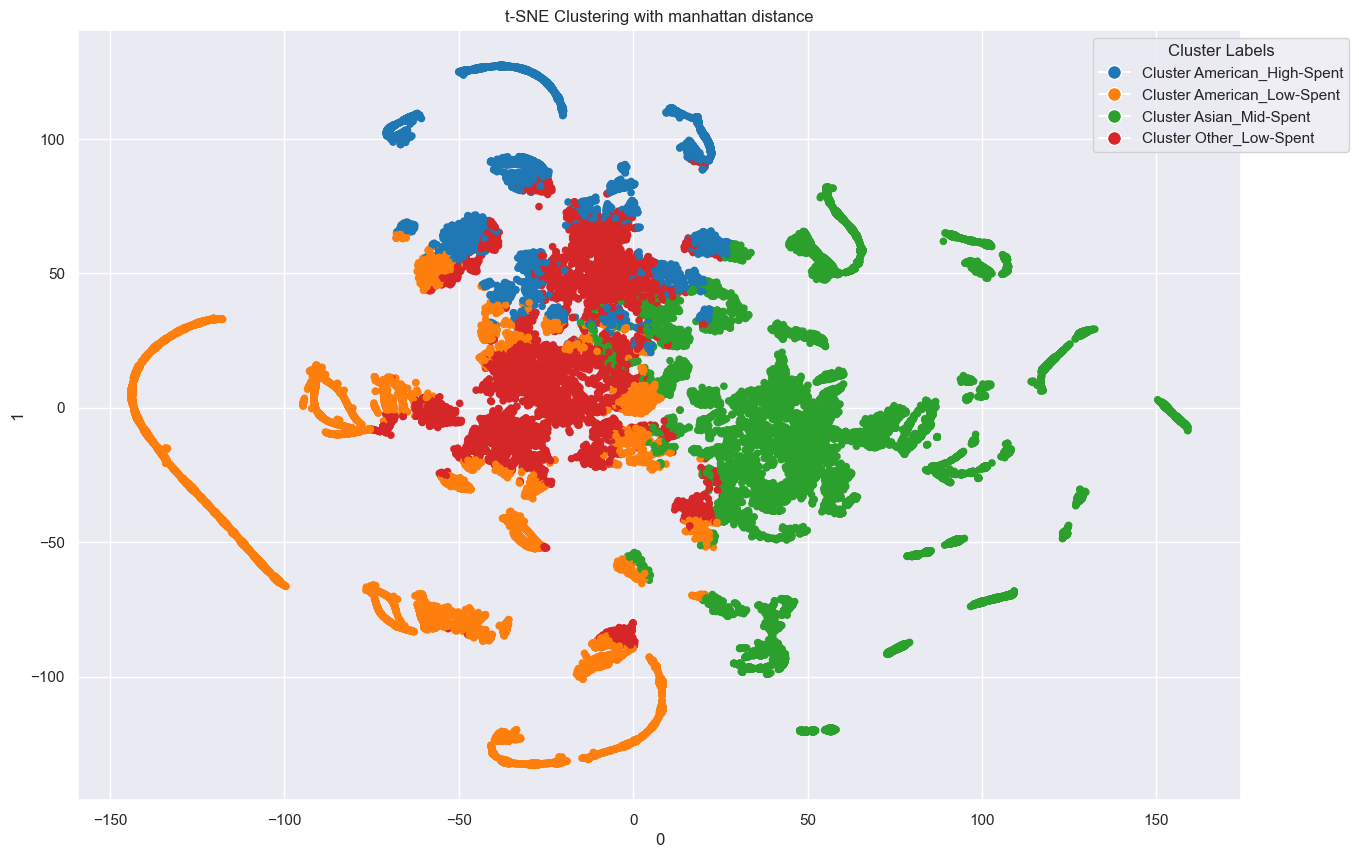

In [292]:
ts = TSNE(random_state=42, perplexity=100, max_iter=5_000, metric="manhattan")

two_dim = ts.fit_transform(df[columns_to_use])


unique_labels = sorted(df["merged_labels"].unique())  
colors = sns.color_palette("tab10", len(unique_labels)) 
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}
mapped_colors = df['merged_labels'].map(color_map)

pd.DataFrame(two_dim).plot.scatter(x=0, y=1, c=mapped_colors, figsize=(15,10))


handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], markersize=10, label=f'Cluster {label}')
    for i, label in enumerate(sorted(unique_labels))
]

plt.legend(
    handles=handles, 
    title="Cluster Labels", 
    loc='upper right', 
    bbox_to_anchor=(1.1, 1.0)
)
plt.title("t-SNE Clustering with manhattan distance")
plt.show()

In [293]:
ts.kl_divergence_

0.9577703475952148

In [294]:
#!pip install umap
#!pip install umap-learn
import umap

c:\Users\gaspa\anaconda3\envs\DM2425\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'UMAP projection of the Cluster Labels')

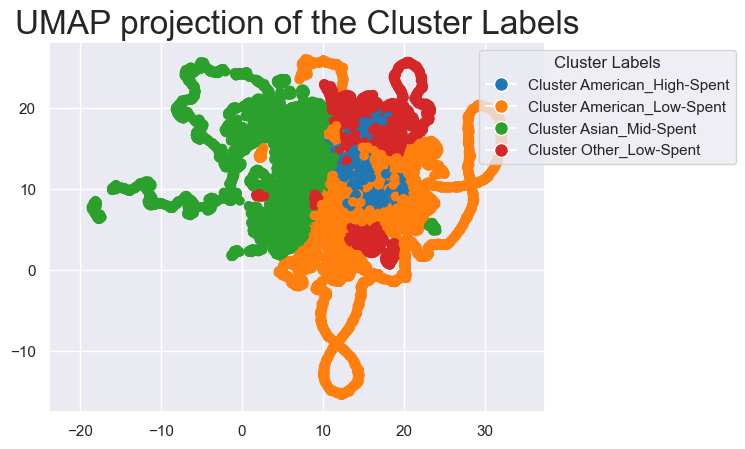

In [383]:
reducer = umap.UMAP(random_state=42, n_neighbors=200, min_dist=0.9, metric="manhattan", n_epochs=3_000)

embedding = reducer.fit_transform(df[columns_to_use])


unique_labels = sorted(df["merged_labels"].unique())  
colors = sns.color_palette("tab10", len(unique_labels)) 
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}
mapped_colors = df['merged_labels'].map(color_map)

plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=mapped_colors)
plt.gca().set_aspect('equal', 'datalim')

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], markersize=10, label=f'Cluster {label}')
    for i, label in enumerate(sorted(unique_labels))
]

plt.legend(
    handles=handles, 
    title="Cluster Labels", 
    loc='upper right', 
    bbox_to_anchor=(1.4, 1.0)
)

plt.title('UMAP projection of the Cluster Labels', fontsize=24)

# Feature importances

In [296]:
from sklearn.model_selection import train_test_split

X = df[columns_to_use]
y = df.merged_labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


dt = DecisionTreeClassifier(random_state=42, max_depth=11)
# max_depth of 11 was the one with higher validation score
dt.fit(X_train, y_train)
print("It is estimated that in average, we are able to predict {0:.2f}% of the customers correctly".format(dt.score(X_test, y_test)*100))

It is estimated that in average, we are able to predict 98.57% of the customers correctly


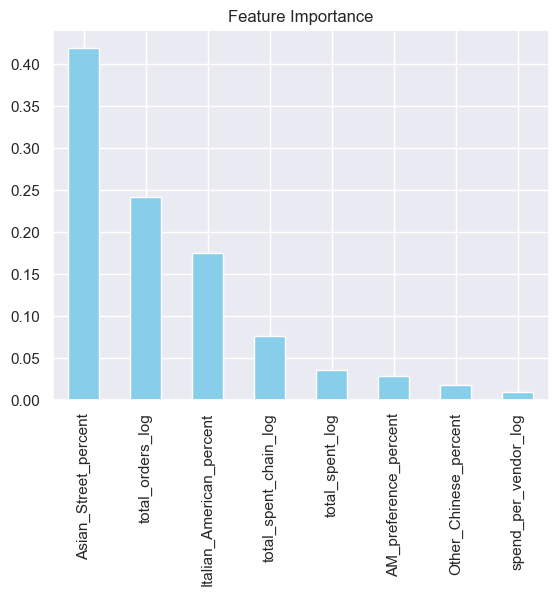

In [297]:
pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title("Feature Importance")
plt.show()

# Reclassify Outliers

In [298]:
df_out = pd.read_csv("DBSCAN_OUTLIERS.csv")

In [299]:
df_out['merged_labels'] = dt.predict(df_out[columns_to_use])
df_out.head()

,customer_id,customer_age,vendor_count,product_count,is_chain,first_order,last_order,CUI_American,CUI_Asian,CUI_Beverages,...,last_promo_DISCOUNT,last_promo_FREEBIE,last_promo_NO PROMO,payment_method_CARD,payment_method_CASH,payment_method_DIGI,customer_activity_Active,customer_activity_Churning,customer_activity_Recent,merged_labels
0,2a8b7853c2,21,3,4,0,0.0,0.533333,0.022481,0.013777,0.0,...,False,False,True,True,False,False,False,True,False,American_Low-Spent
1,aede6a3935,25,2,3,0,0.0,0.566667,0.000000,0.040841,0.0,...,False,False,True,False,True,False,False,True,False,Asian_Mid-Spent
2,c2292f1df6,24,3,6,0,0.0,0.722222,0.000000,0.057024,0.0,...,False,False,True,True,False,False,True,False,False,Asian_Mid-Spent
3,db250450d8,39,4,23,0,0.0,0.777778,0.000000,0.546108,0.0,...,False,False,False,False,False,True,True,False,False,Asian_Mid-Spent
4,07a6c93ec8,37,6,11,0,0.0,0.866667,0.083581,0.000000,0.0,...,False,False,True,False,True,False,True,False,False,American_High-Spent


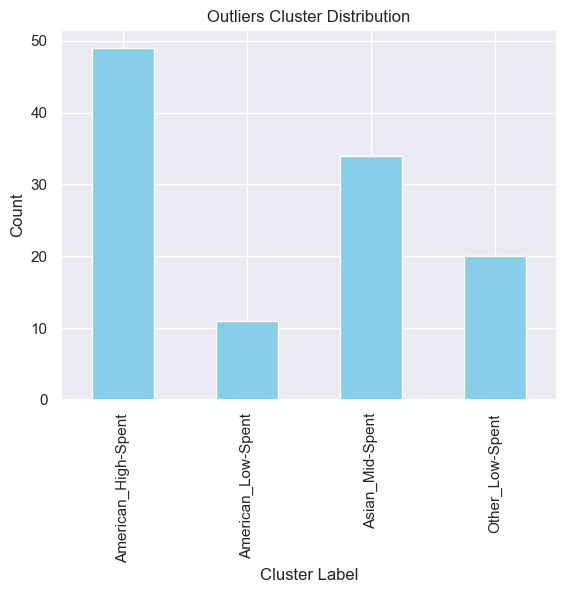

In [300]:
df_out['merged_labels'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.title('Outliers Cluster Distribution')
plt.show()